In [ ]:
# MULTI-THREADED DATA PREP
import os
import shutil
import pandas as pd
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import warnings

# Suppress the pandas warning
warnings.simplefilter(action='ignore', category=DeprecationWarning)

# Configuration
SOURCE_ROOT = "/content/drive/MyDrive/pose-guided-diffusion-analysis/datasets_unzipped/HumanArt_v1"
PARQUET_PATH = "/content/drive/MyDrive/pose-guided-diffusion-analysis/processed_data/full_humanart_dataset.parquet"
DEST_ROOT = "/content/local_data"
TARGET_SIZE = 20000

print("Starting Optimized Data Prep...")

# 1. Load Data
df = pd.read_parquet(PARQUET_PATH)
unique_images = df.groupby('image_id')[['relative_path', 'category']].first().reset_index()

# 2. Smart Sampling
print(f"Sampling {TARGET_SIZE} images from {len(unique_images)} total...")
sampled_images = unique_images.groupby('category', group_keys=False).apply(
    lambda x: x.sample(min(len(x), int(TARGET_SIZE / unique_images['category'].nunique() * 1.5)))
).sample(TARGET_SIZE)

# 3. FAST Parallel Copy
os.makedirs(DEST_ROOT, exist_ok=True)

def copy_single_image(row):
    # Fix source path
    rel_path = row['relative_path']
    if rel_path.startswith("HumanArt/"): rel_path = rel_path.replace("HumanArt/", "", 1)

    src = os.path.join(SOURCE_ROOT, rel_path)

    # Destination Path (Flattened)
    ext = os.path.splitext(rel_path)[1]
    new_filename = f"{row['image_id']}{ext}"
    dst = os.path.join(DEST_ROOT, new_filename)

    try:
        if not os.path.exists(dst): # Don't overwrite if exists
            shutil.copy(src, dst)
        return True
    except Exception:
        return False

print(f"Copying files using 16 threads...")
rows_to_process = [row for _, row in sampled_images.iterrows()]

# The Magic: ThreadPoolExecutor
with ThreadPoolExecutor(max_workers=16) as executor:
    results = list(tqdm(executor.map(copy_single_image, rows_to_process), total=len(rows_to_process)))

print(f"Copied {sum(results)} images.")

# 4. Save Training Index
def update_path_to_local(row):
    ext = os.path.splitext(row['relative_path'])[1]
    return f"{row['image_id']}{ext}"

# Filter the main dataframe to match our sampled images
df_subset = df[df['image_id'].isin(sampled_images['image_id'])].copy()
df_subset['local_path'] = df_subset.apply(update_path_to_local, axis=1)

FAST_PARQUET = "/content/local_humanart_subset.parquet"
df_subset.to_parquet(FAST_PARQUET)
print(f"💾 Saved fast training index to: {FAST_PARQUET}")

🚀 Starting Optimized Data Prep...
Sampling 20000 images from 33250 total...
📦 Copying files using 16 threads...


  0%|          | 0/20000 [00:00<?, ?it/s]

✅ Copied 20000 images.
💾 Saved fast training index to: /content/local_humanart_subset.parquet


In [ ]:
# BLOCK 1: INSTALL DEPENDENCIES
# Run this once.
!pip install -q diffusers transformers accelerate xformers opencv-python-headless
!pip install -q pyarrow pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import cv2
import math
import torch
import numpy as np

# --- HELPER: Draw COCO Skeletons from Keypoints ---
# The model needs a black image with colored/white sticks, not JSON numbers.
class PoseRenderer:
    def __init__(self):
        # COCO 17-keypoint connections
        self.edges = [
            (0,1), (0,2), (1,3), (2,4), # Face
            (5,6), (5,7), (7,9), (6,8), (8,10), # Arms
            (5,11), (6,12), (11,12), # Torso
            (11,13), (13,15), (12,14), (14,16) # Legs
        ]
        # Colors (BGR) - simplified to stick colors
        self.colors = [[255, 0, 0], [255, 85, 0], [255, 170, 0], [255, 255, 0],
                       [170, 255, 0], [85, 255, 0], [0, 255, 0], [0, 255, 85],
                       [0, 255, 170], [0, 255, 255], [0, 170, 255], [0, 85, 255],
                       [0, 0, 255], [85, 0, 255], [170, 0, 255], [255, 0, 255]]

    def draw_pose(self, img_h, img_w, all_keypoints):
        """
        all_keypoints: List of people. Each person is a list of 17*3 numbers (x, y, v).
        Returns: A black image with colored skeletons.
        """
        canvas = np.zeros((img_h, img_w, 3), dtype=np.uint8)

        for person_kpts in all_keypoints:
            # Reshape flat list to (17, 3)
            kpts = np.array(person_kpts).reshape(-1, 3)

            # Draw Limbs
            for i, (start_idx, end_idx) in enumerate(self.edges):
                if start_idx >= len(kpts) or end_idx >= len(kpts): continue

                start = kpts[start_idx]
                end = kpts[end_idx]

                # Check visibility (v > 0)
                if start[2] > 0 and end[2] > 0:
                    cv2.line(canvas, (int(start[0]), int(start[1])),
                             (int(end[0]), int(end[1])), self.colors[i%len(self.colors)], 3)

            # Draw Points (Joints)
            for i, (x, y, v) in enumerate(kpts):
                if v > 0:
                    cv2.circle(canvas, (int(x), int(y)), 4, (255, 255, 255), -1)

        return canvas

renderer = PoseRenderer()
print("Configuration and Renderer Ready.")
class TrainingConfig:
    train_batch_size = 16          # Increased to 16 (A100 can handle it)
    gradient_accumulation_steps = 1 # Remove accum if batch size is 16, faster loop
    learning_rate = 1e-5

    # Train by Steps, not Epochs
    max_train_steps = 15000       # Target ~6-8 hours
    save_steps = 2500             # Save every ~1 hour

    image_resolution = 512
    mixed_precision = "fp16"
    output_dir = "/content/drive/MyDrive/t2i_adapter_humanart_v1"

    # USE THE LOCAL PATHS
    parquet_path = "/content/local_humanart_subset.parquet"
    image_root = "/content/local_data" # Reading from here is instant

✅ Configuration and Renderer Ready.


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image


class FastHumanArtDataset(Dataset):
    def __init__(self, parquet_file, root_dir, renderer):
        self.root_dir = root_dir
        self.renderer = renderer

        df = pd.read_parquet(parquet_file)

        # Group by image_id
        self.data = df.groupby('image_id').agg({
            'local_path': 'first',
            'description': 'first',
            'keypoints': list
        }).reset_index()

        self.transform = transforms.Compose([
            transforms.Resize((TrainingConfig.image_resolution, TrainingConfig.image_resolution)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        self.cond_transform = transforms.Compose([
            transforms.Resize((TrainingConfig.image_resolution, TrainingConfig.image_resolution)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Load from LOCAL disk (Fast!)
        img_path = os.path.join(self.root_dir, row['local_path'])

        try:
            image = Image.open(img_path).convert("RGB")
            w, h = image.size
        except:
            # Fallback
            return self.__getitem__((idx + 1) % len(self))

        # Generate Pose Map
        pose_img_cv2 = self.renderer.draw_pose(h, w, row['keypoints'])
        pose_image = Image.fromarray(pose_img_cv2)

        return {
            "pixel_values": self.transform(image),
            "condition_pixel_values": self.cond_transform(pose_image),
            "input_ids": row['description']
        }

# Re-init dataloader with num_workers=4 (A100 has many CPU cores)
dataset = FastHumanArtDataset(TrainingConfig.parquet_path, TrainingConfig.image_root, renderer)
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=TrainingConfig.train_batch_size, shuffle=True, num_workers=4, pin_memory=True
)

In [ ]:
from diffusers import AutoencoderKL, UNet2DConditionModel, T2IAdapter, DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel

device = "cuda"

# 1. Load Components
print("Loading SD v1.5 components...")
tokenizer = CLIPTokenizer.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="unet").to(device)

# 2. Freeze Base Models (Crucial!)
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

# 3. Initialize Adapter
# We create a lightweight adapter.
# channels=[320, 640, 1280, 1280] matches SD v1.5 UNet structure
print("Initializing T2I-Adapter...")
adapter = T2IAdapter(
    in_channels=3,
    channels=[320, 640, 1280, 1280],
    num_res_blocks=2,
    downscale_factor=8
).to(device)

# 4. Optimizer
optimizer = torch.optim.AdamW(adapter.parameters(), lr=TrainingConfig.learning_rate)
noise_scheduler = DDPMScheduler.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="scheduler")

print(" Model setup complete. Only 'adapter' is trainable.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading SD v1.5 components...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Initializing T2I-Adapter...
✅ Model setup complete. Only 'adapter' is trainable.


In [ ]:
from tqdm.auto import tqdm
import torch.nn.functional as F
import csv

global_step = 0
print(f"Starting High-Speed Training for {TrainingConfig.max_train_steps} steps...")

# List to store loss values
loss_history = []
log_path = os.path.join(TrainingConfig.output_dir, "training_logs.csv")

# Create the CSV file with headers
with open(log_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "loss"])

progress_bar = tqdm(total=TrainingConfig.max_train_steps)

while global_step < TrainingConfig.max_train_steps:
    adapter.train()

    for step, batch in enumerate(train_dataloader):
        pixel_values = batch["pixel_values"].to(device)
        condition_values = batch["condition_pixel_values"].to(device)
        prompts = batch["input_ids"]

        # 1. Text Embeddings
        with torch.no_grad():
            inputs = tokenizer(prompts, max_length=tokenizer.model_max_length, padding="max_length", truncation=True, return_tensors="pt")
            encoder_hidden_states = text_encoder(inputs.input_ids.to(device))[0]
            latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor

        # 2. Noise & Timesteps
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 3. Forward Pass
        adapter_features = adapter(condition_values)
        model_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=encoder_hidden_states,
            down_intrablock_additional_residuals=[sample.to(dtype=torch.float16) for sample in adapter_features]
        ).sample

        # 4. Loss & Backprop
        loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # 5. LOGGING (New Part)
        current_loss = loss.item()
        loss_history.append(current_loss)

        # Save to CSV every 100 steps (Safe against crashing)
        if global_step % 100 == 0:
            with open(log_path, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([global_step, current_loss])

        progress_bar.update(1)
        progress_bar.set_postfix({"loss": current_loss})
        global_step += 1

        # Save Model Checkpoint
        if global_step % TrainingConfig.save_steps == 0:
            save_path = os.path.join(TrainingConfig.output_dir, f"checkpoint-step-{global_step}")
            adapter.save_pretrained(save_path)
            print(f"💾 Saved checkpoint to {save_path}")

        if global_step >= TrainingConfig.max_train_steps:
            break

print("🎉 Training Complete! Logs saved to Drive.")

🚀 Starting High-Speed Training for 15000 steps...


  0%|          | 0/15000 [00:00<?, ?it/s]

💾 Saved checkpoint to /content/drive/MyDrive/t2i_adapter_humanart_v1/checkpoint-step-2500
💾 Saved checkpoint to /content/drive/MyDrive/t2i_adapter_humanart_v1/checkpoint-step-5000
💾 Saved checkpoint to /content/drive/MyDrive/t2i_adapter_humanart_v1/checkpoint-step-7500
💾 Saved checkpoint to /content/drive/MyDrive/t2i_adapter_humanart_v1/checkpoint-step-10000
💾 Saved checkpoint to /content/drive/MyDrive/t2i_adapter_humanart_v1/checkpoint-step-12500
💾 Saved checkpoint to /content/drive/MyDrive/t2i_adapter_humanart_v1/checkpoint-step-15000
🎉 Training Complete! Logs saved to Drive.


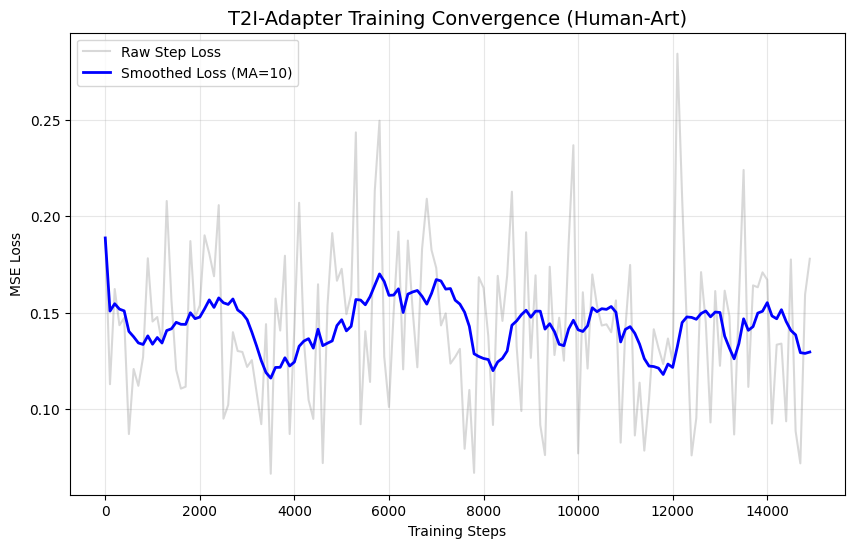

In [1]:
log_path = "/content/drive/MyDrive/t2i_adapter_humanart_v1/training_logs.csv"
df_log = pd.read_csv(log_path)
plt.figure(figsize=(10, 6))
plt.plot(df_log['step'], df_log['loss'], alpha=0.3, color='gray', label='Raw Step Loss')
df_log['smooth_loss'] = df_log['loss'].rolling(window=10, min_periods=1).mean()
plt.plot(df_log['step'], df_log['smooth_loss'], color='blue', linewidth=2, label='Smoothed Loss (MA=10)')
plt.title("T2I-Adapter Training Convergence (Human-Art)", fontsize=14)
plt.xlabel("Training Steps")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("corrected_loss_graph.png")
plt.show()